<a href="https://colab.research.google.com/github/PapiWinnie/Formative_1-Building_a_Pipeline_for_TimeSeriesData/blob/main/traffic_volume_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv('/content/Metro_Interstate_Traffic_Volume.csv')
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


In [3]:
df.isnull().sum()

,0
traffic_volume,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0


Handling missing values

In [4]:
df["holiday"] = df["holiday"].fillna("None")
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,None,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,None,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,None,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,None,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,None,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


In [5]:
df.describe()

,traffic_volume,temp,rain_1h,snow_1h,clouds_all
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,3259.818355,281.205870,0.334264,0.000222,49.362231
std,1986.860670,13.338232,44.789133,0.008168,39.015750
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1193.000000,272.160000,0.000000,0.000000,1.000000
50%,3380.000000,282.450000,0.000000,0.000000,64.000000
75%,4933.000000,291.806000,0.000000,0.000000,90.000000
max,7280.000000,310.070000,9831.300000,0.510000,100.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   traffic_volume       48204 non-null  int64  
 1   holiday              48204 non-null  object 
 2   temp                 48204 non-null  float64
 3   rain_1h              48204 non-null  float64
 4   snow_1h              48204 non-null  float64
 5   clouds_all           48204 non-null  int64  
 6   weather_main         48204 non-null  object 
 7   weather_description  48204 non-null  object 
 8   date_time            48204 non-null  object 
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [7]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   traffic_volume       48204 non-null  int64         
 1   holiday              48204 non-null  object        
 2   temp                 48204 non-null  float64       
 3   rain_1h              48204 non-null  float64       
 4   snow_1h              48204 non-null  float64       
 5   clouds_all           48204 non-null  int64         
 6   weather_main         48204 non-null  object        
 7   weather_description  48204 non-null  object        
 8   date_time            48204 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 3.3+ MB


Range of the dataset

In [8]:
date_time = df['date_time']

In [9]:
start_date = date_time.min()
print(start_date)

2012-10-02 09:00:00


In [10]:
end_date = date_time.max()
print(end_date)

2018-09-30 23:00:00


Frequency of the records

In [11]:
df = df.sort_values("date_time")

In [12]:
df["time_diff"] = df["date_time"].diff()
df["time_diff"].value_counts().head()

,count
time_diff,
0 days 01:00:00,37986
0 days 00:00:00,7629
0 days 02:00:00,2192
0 days 03:00:00,201
0 days 04:00:00,59


#Analytical Questions

Does traffic volume increase or decrrease over the years ?

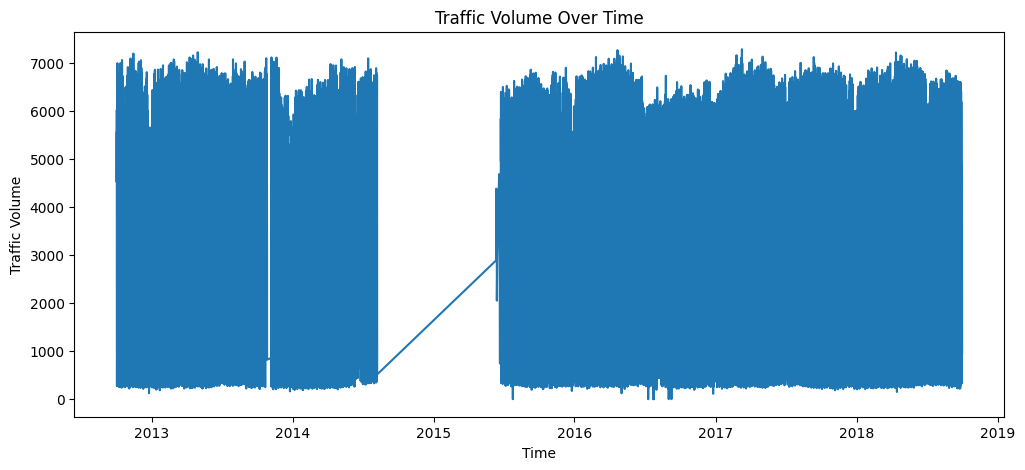

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["date_time"], df["traffic_volume"])
plt.title("Traffic Volume Over Time")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.show()

How does holidays impact traffic volumes?

In [14]:
# Creating a binary variable or 0 not holiday and 1 for is holiday
df["holiday"] = df["holiday"].fillna("None")
df["is_holiday"] = (df["holiday"] != "None").astype(int)

In [15]:
holiday_avg = df.groupby("is_holiday")["traffic_volume"].mean()
holiday_avg

,traffic_volume
is_holiday,
0,3262.852170
1,865.442623


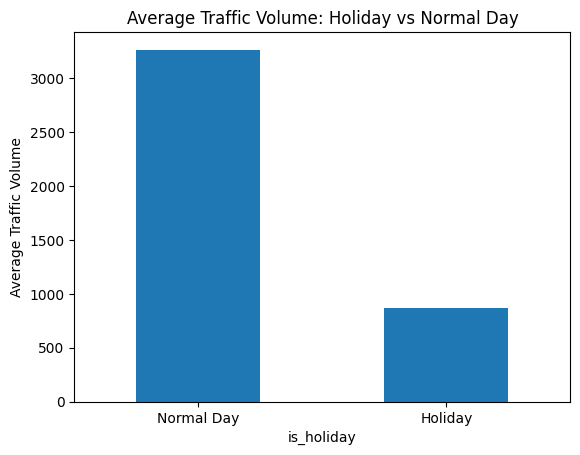

In [16]:
import matplotlib.pyplot as plt

holiday_avg.plot(kind="bar")
plt.xticks([0,1], ["Normal Day", "Holiday"], rotation=0)
plt.title("Average Traffic Volume: Holiday vs Normal Day")
plt.ylabel("Average Traffic Volume")
plt.show()

The graph shows that traffic volume is significantly higher on a mormal day than on holidays. This makes sense because on holidays a lot of people have already traveled to their homes to celebrate and only a few people go to work.

Does a 24-hour Moving Average Reveal Underlying Trends in Traffic Volume?

In [17]:
df['ma_24'] = df['traffic_volume'].rolling(window=24).mean()
df['ma_168'] = df['traffic_volume'].rolling(window=168).mean()  # 7 days

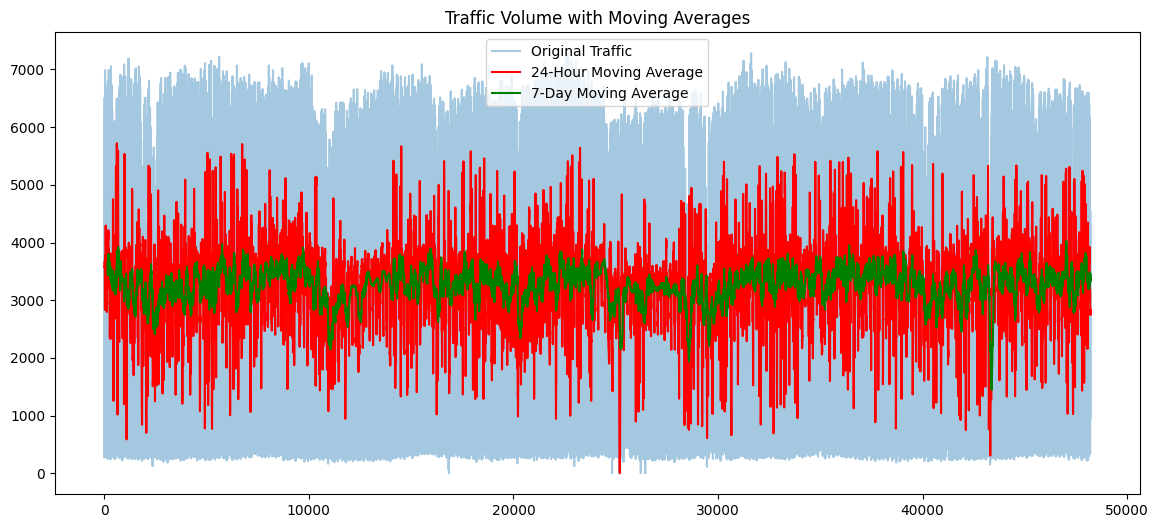

In [18]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['traffic_volume'], alpha=0.4, label='Original Traffic')
plt.plot(df.index, df['ma_24'], color='red', label='24-Hour Moving Average')
plt.plot(df.index, df['ma_168'], color='green', label='7-Day Moving Average')

plt.title("Traffic Volume with Moving Averages")
plt.legend()
plt.show()

Is current traffic volume influenced by traffic in previous hours? (Lag Analysis)

In [19]:
# Create lag features
df['lag_1'] = df['traffic_volume'].shift(1)      # 1 hour before
df['lag_24'] = df['traffic_volume'].shift(24)    # 24 hours before

# Drop NaNs caused by shifting
lag_df = df[['traffic_volume', 'lag_1', 'lag_24']].dropna()

In [20]:
# Correlation with Lag Features
lag_corr = lag_df.corr()

print("Correlation with Current Traffic Volume:")
print(lag_corr['traffic_volume'])

Correlation with Current Traffic Volume:
traffic_volume    1.000000
lag_1             0.912708
lag_24            0.369515
Name: traffic_volume, dtype: float64


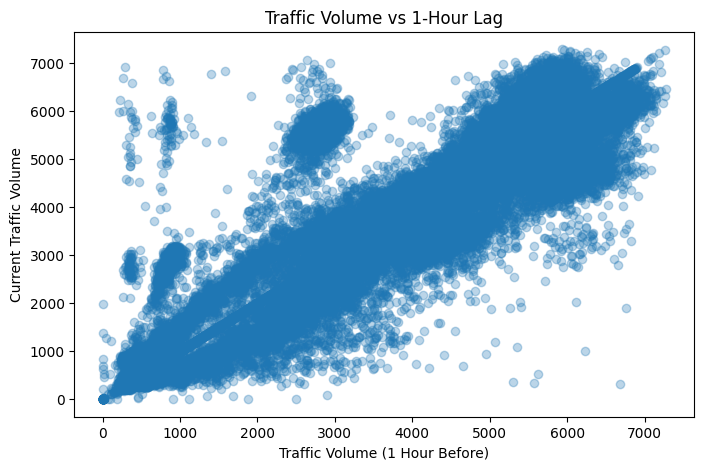

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(lag_df['lag_1'], lag_df['traffic_volume'], alpha=0.3)
plt.title("Traffic Volume vs 1-Hour Lag")
plt.xlabel("Traffic Volume (1 Hour Before)")
plt.ylabel("Current Traffic Volume")
plt.show()

## Create Monthly Lag Feature

### Subtask:
Create a new lagged feature, `lag_720`, representing the traffic volume from approximately 30 days (720 hours) prior. This will help us understand monthly patterns.


In [22]:
df['lag_720'] = df['traffic_volume'].shift(720)
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,time_diff,is_holiday,ma_24,ma_168,lag_1,lag_24,lag_720
0,5545,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,NaT,0,NaN,NaN,NaN,NaN,NaN
1,4516,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,0 days 01:00:00,0,NaN,NaN,5545.0,NaN,NaN
2,4767,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,0 days 01:00:00,0,NaN,NaN,4516.0,NaN,NaN
3,5026,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,0 days 01:00:00,0,NaN,NaN,4767.0,NaN,NaN
4,4918,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,0 days 01:00:00,0,NaN,NaN,5026.0,NaN,NaN


In [23]:
lag_720_df = df[['traffic_volume', 'lag_720']].dropna()
lag_720_corr = lag_720_df.corr()

print("Correlation with Current Traffic Volume and 720-Hour Lag:")
print(lag_720_corr['traffic_volume'])

Correlation with Current Traffic Volume and 720-Hour Lag:
traffic_volume    1.000000
lag_720           0.020911
Name: traffic_volume, dtype: float64


**Reasoning**:
To visually represent the relationship between current traffic volume and the 720-hour lagged traffic volume, I will generate a scatter plot using the `lag_720_df` DataFrame.



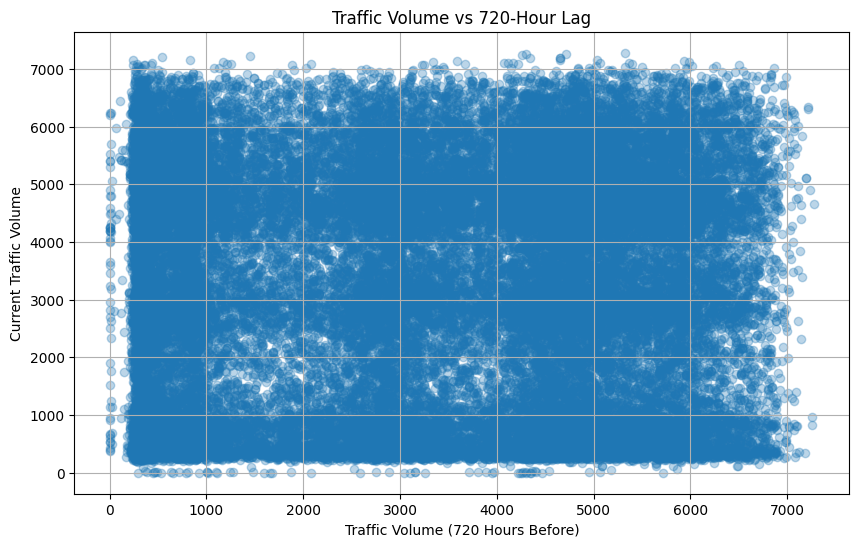

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(lag_720_df['lag_720'], lag_720_df['traffic_volume'], alpha=0.3)
plt.title("Traffic Volume vs 720-Hour Lag")
plt.xlabel("Traffic Volume (720 Hours Before)")
plt.ylabel("Current Traffic Volume")
plt.grid(True)
plt.show()

## Summary:

### Data Analysis Key Findings
*   A new feature, `lag_720`, was successfully created, representing the traffic volume from 720 hours (approximately 30 days) prior.
*   The correlation coefficient between the current `traffic_volume` and `lag_720` was found to be approximately 0.020911.
*   This correlation indicates a very weak positive linear relationship between the current traffic volume and the traffic volume from 30 days prior.
*   A scatter plot visualization of the relationship between current traffic volume and `lag_720` visually supported the low correlation, showing no distinct pattern or trend.

### Insights or Next Steps
*   The extremely low correlation suggests that a direct lag of 30 days in traffic volume has negligible predictive power for current traffic flow, indicating that monthly patterns might not be a strong standalone factor for forecasting.
*   Future analysis should investigate other lag periods, such as 24-hour (daily) or 168-hour (weekly) lags, which are more likely to capture significant temporal dependencies in traffic patterns.


# Model Training

In [25]:
# Encoding the categorical variables
categorical_cols = ["holiday", "weather_main", "weather_description"]

# Filter out columns that are no longer present in the DataFrame
cols_to_encode_now = [col for col in categorical_cols if col in df.columns]

if cols_to_encode_now:
    df = pd.get_dummies(df, columns=cols_to_encode_now, drop_first=True)
else:
    print(f"All specified categorical columns ({', '.join(categorical_cols)}) were already encoded or are not present in the DataFrame.")

### Train Test Split

In [26]:
# Drop 'time_diff' if it exists, as it was a timedelta type that might have caused issues or NaNs.
# Ensure all feature engineering is complete before this step.
if 'time_diff' in df.columns:
    df = df.drop('time_diff', axis=1)

# Drop any remaining rows with NaN values after all feature creation (e.g., from rolling averages or lag features)
df_cleaned = df.dropna()


train_size = int(len(df_cleaned) * 0.8)

train = df_cleaned[:train_size]
test = df_cleaned[train_size:]

X_train = train.drop(["traffic_volume", "date_time"], axis=1)
y_train = train["traffic_volume"]

X_test = test.drop(["traffic_volume", "date_time"], axis=1)
y_test = test["traffic_volume"]

### Linear Regression Model

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np # Import numpy for np.sqrt

# Diagnostic: Check for NaNs before model training
print("NaNs in X_train before fit:\n", X_train.isnull().sum()[X_train.isnull().sum() > 0])
print("NaNs in X_test before fit:\n", X_test.isnull().sum()[X_test.isnull().sum() > 0])

model1 = LinearRegression()
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

mae1 = mean_absolute_error(y_test, pred1)
rmse1 = np.sqrt(mean_squared_error(y_test, pred1))

print("Experiment 1 - Linear Regression")
print("MAE:", mae1)
print("RMSE:", rmse1)

NaNs in X_train before fit:
 Series([], dtype: int64)
NaNs in X_test before fit:
 Series([], dtype: int64)
Experiment 1 - Linear Regression
MAE: 490.12947091258764
RMSE: 685.4512029729037


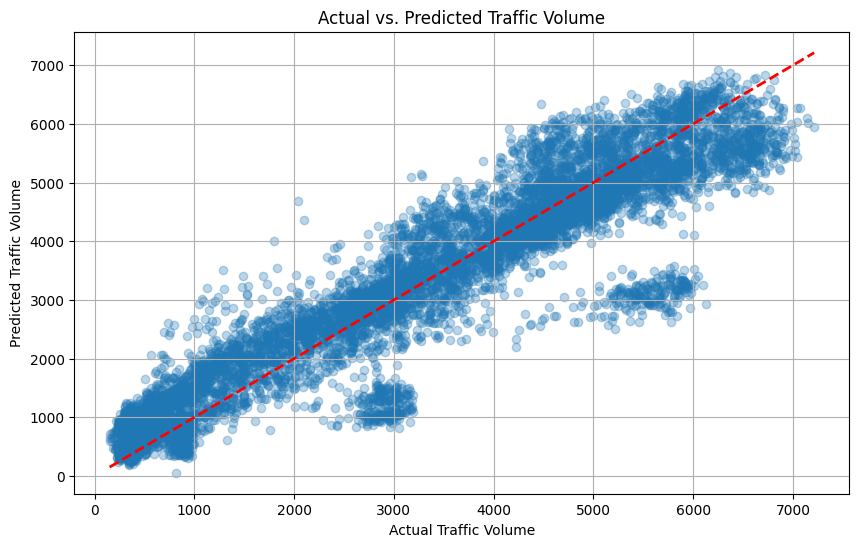

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred1, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Red dashed line for ideal prediction
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs. Predicted Traffic Volume")
plt.grid(True)
plt.show()

Overall, the plot visually confirms that the model captures the general trend of traffic volume but has room for improvement in predicting extreme values or reducing prediction errors across the board.



In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize and train the Random Forest Regressor model
model2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_estimators can be tuned
model2.fit(X_train, y_train)

# Make predictions on the test set
pred2 = model2.predict(X_test)

# Evaluate the model
mae2 = mean_absolute_error(y_test, pred2)
rmse2 = np.sqrt(mean_squared_error(y_test, pred2))

print("Experiment 2 - Random Forest Regression")
print("MAE:", mae2)
print("RMSE:", rmse2)

Experiment 2 - Random Forest Regression
MAE: 377.67659892597663
RMSE: 553.0204014386356


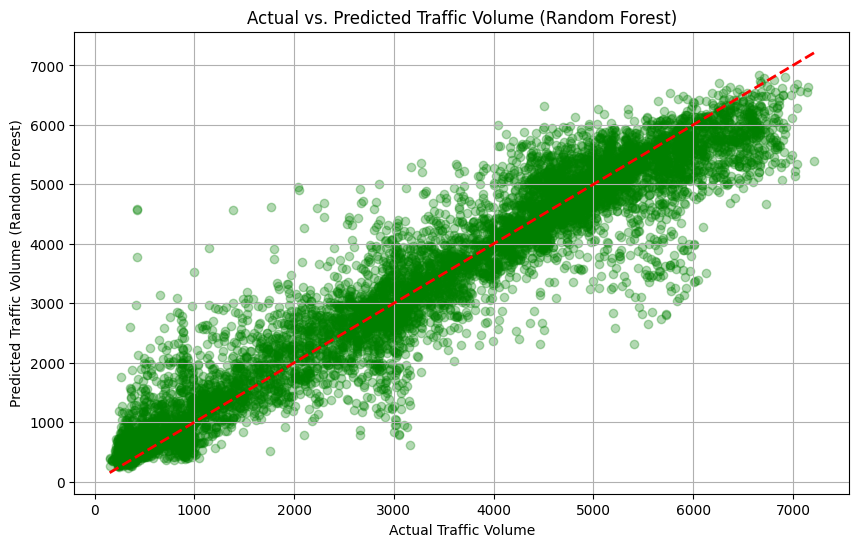

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred2, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Red dashed line for ideal prediction
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume (Random Forest)")
plt.title("Actual vs. Predicted Traffic Volume (Random Forest)")
plt.grid(True)
plt.show()

This plot indicates that the Random Forest model provides a more accurate and robust prediction of traffic volume compared to the Linear Regression model for this dataset.



In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 15]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=3)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Initialize and train the Random Forest Regressor model with best parameters
model_optimized = RandomForestRegressor(n_estimators=grid.best_params_['n_estimators'],
                                        max_depth=grid.best_params_['max_depth'],
                                        random_state=42, n_jobs=-1)
model_optimized.fit(X_train, y_train)

# Make predictions on the test set
pred_optimized = model_optimized.predict(X_test)

# Evaluate the model
mae_optimized = mean_absolute_error(y_test, pred_optimized)
rmse_optimized = np.sqrt(mean_squared_error(y_test, pred_optimized))

print("Experiment 3 - Optimized Random Forest Regression")
print("MAE:", mae_optimized)
print("RMSE:", rmse_optimized)

Experiment 3 - Optimized Random Forest Regression
MAE: 379.5603865003941
RMSE: 546.20366590928


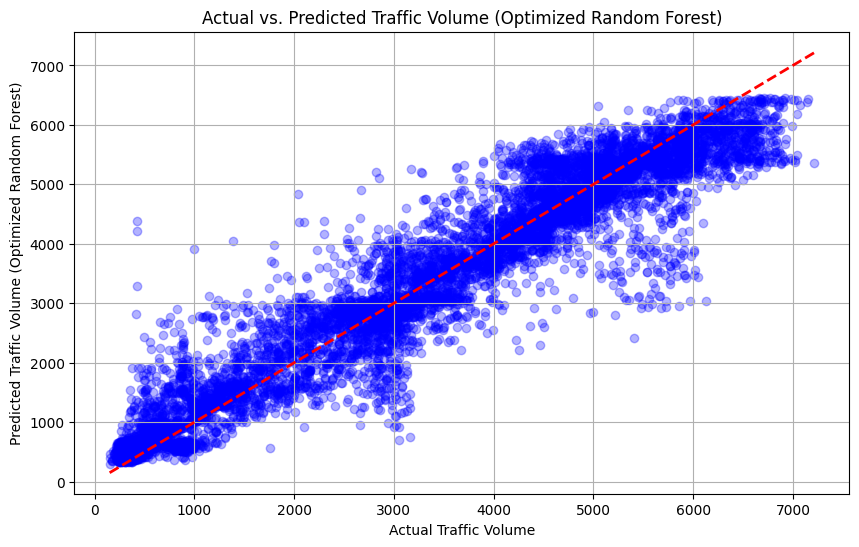

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred_optimized, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Red dashed line for ideal prediction
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume (Optimized Random Forest)")
plt.title("Actual vs. Predicted Traffic Volume (Optimized Random Forest)")
plt.grid(True)
plt.show()

## Compare Model Performance


In [34]:
import pandas as pd

# Create a dictionary to hold the metrics
metrics_data = {
    'Model': ['Linear Regression', 'Random Forest (Initial)', 'Random Forest (Optimized)'],
    'MAE': [mae1, mae2, mae_optimized],
    'RMSE': [rmse1, rmse2, rmse_optimized]
}

# Create the DataFrame
comparison_df = pd.DataFrame(metrics_data)

# Print the comparison table
print("\nModel Performance Comparison:")
print(comparison_df.set_index('Model'))


Model Performance Comparison:
                                  MAE        RMSE
Model                                            
Linear Regression          490.129471  685.451203
Random Forest (Initial)    377.676599  553.020401
Random Forest (Optimized)  379.560387  546.203666


In [35]:
import joblib

# Define a filename for the model
model_filename = 'optimized_random_forest_model.joblib'

# Save the trained model to a file
joblib.dump(model_optimized, model_filename)
print(f"Model saved successfully as '{model_filename}'")

Model saved successfully as 'optimized_random_forest_model.joblib'


In [36]:
import joblib

# Define the filename of the saved model
model_filename = 'optimized_random_forest_model.joblib'

# Load the model from the file
loaded_model = joblib.load(model_filename)

print(f"Model loaded successfully from '{model_filename}'")

# You can now use the loaded_model for predictions
# For example, let's make a prediction on the first sample of X_test
# first_test_sample = X_test.iloc[[0]]
# loaded_prediction = loaded_model.predict(first_test_sample)
# print(f"Prediction using loaded model for first test sample: {loaded_prediction[0]:.2f}")

# To verify it's the same model, you could re-evaluate its performance on X_test
# loaded_pred = loaded_model.predict(X_test)
# mae_loaded = mean_absolute_error(y_test, loaded_pred)
# print("MAE with loaded model:", mae_loaded)

Model loaded successfully from 'optimized_random_forest_model.joblib'
